### Add imports

In [16]:
import sys
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from src.llm_client import LLMClient
from src.prompts import build_zero_shot_prompt, DATASET_CONFIG

from src.data_loader import load_churn, load_housing, load_bank
from src.config import FIGURES_DIR

project_root = Path.cwd().parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

### Load Datasets

In [3]:
X_churn, y_churn = load_churn()
X_housing, y_housing = load_housing()
X_bank, y_bank = load_bank()

datasets = {
    "Churn": (X_churn, y_churn),
    "Housing": (X_housing, y_housing),
    "Bank": (X_bank, y_bank),
}

✅ Churn loaded: 7043 rows × 19 features
   Class balance: 26.5% churned
    Dropped 6 cols with >40% missing
✅ Housing loaded: 2930 rows × 73 features
    Target range: $12,789 – $755,000
✅ Bank loaded: 41188 rows × 19 features
   Class balance: 11.3% subscribed


### Check overview

In [4]:
overview = []

for name, (X, y) in datasets.items():
    overview.append({
        "Dataset": name,
        "Rows": X.shape[0],
        "Columns": X.shape[1],
        "Numeric cols": X.select_dtypes(include=np.number).shape[1],
        "Categorical cols": X.select_dtypes(exclude=np.number).shape[1],
        "Missing values (total)": X.isnull().sum().sum(),
        "Target type": "Binary" if y.nunique() == 2 else "Continuous"
    })


pd.DataFrame(overview)

,Dataset,Rows,Columns,Numeric cols,Categorical cols,Missing values (total),Target type
0,Churn,7043,19,4,15,0,Binary
1,Housing,2930,73,36,37,1721,Continuous
2,Bank,41188,19,9,10,0,Binary


### Target distributions

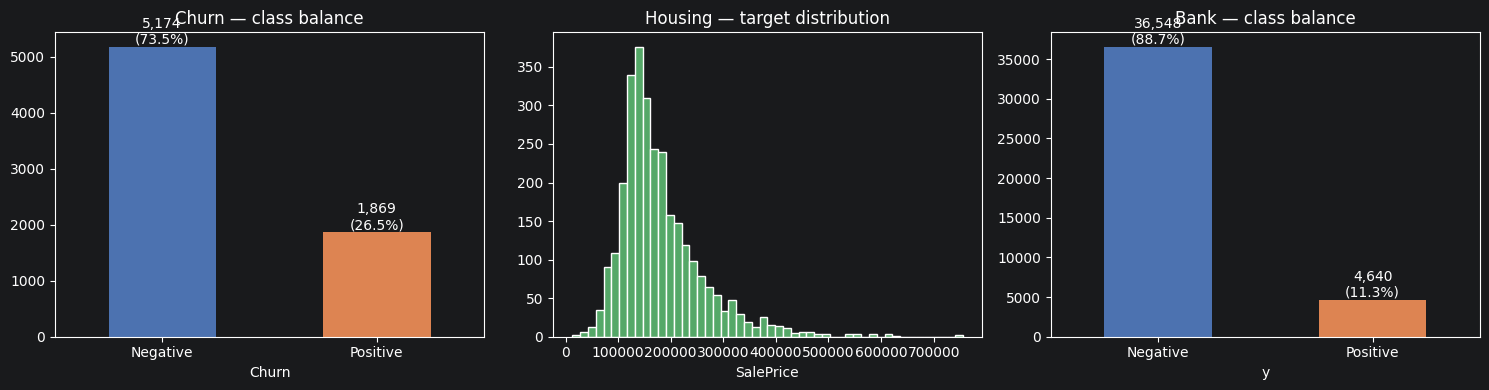

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (name, (X, y)) in zip(axes, datasets.items()):
  if y.nunique() == 2:
      y.value_counts().plot.bar(ax=ax, color=["#4C72B0", "#DD8452"])
      ax.set_title(f"{name} — class balance")
      ax.set_xticklabels(["Negative", "Positive"], rotation=0)
      for i, v in enumerate(y.value_counts()):
          ax.text(i, v, f"{v:,}\n({v/len(y):.1%})", ha="center", va="bottom")
  else:
      ax.hist(y, bins=50, color="#55A868", edgecolor="white")
      ax.set_title(f"{name} — target distribution")
      ax.set_xlabel(y.name)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "01_target_distributions.png", bbox_inches="tight")
plt.show()

### Check Missing values

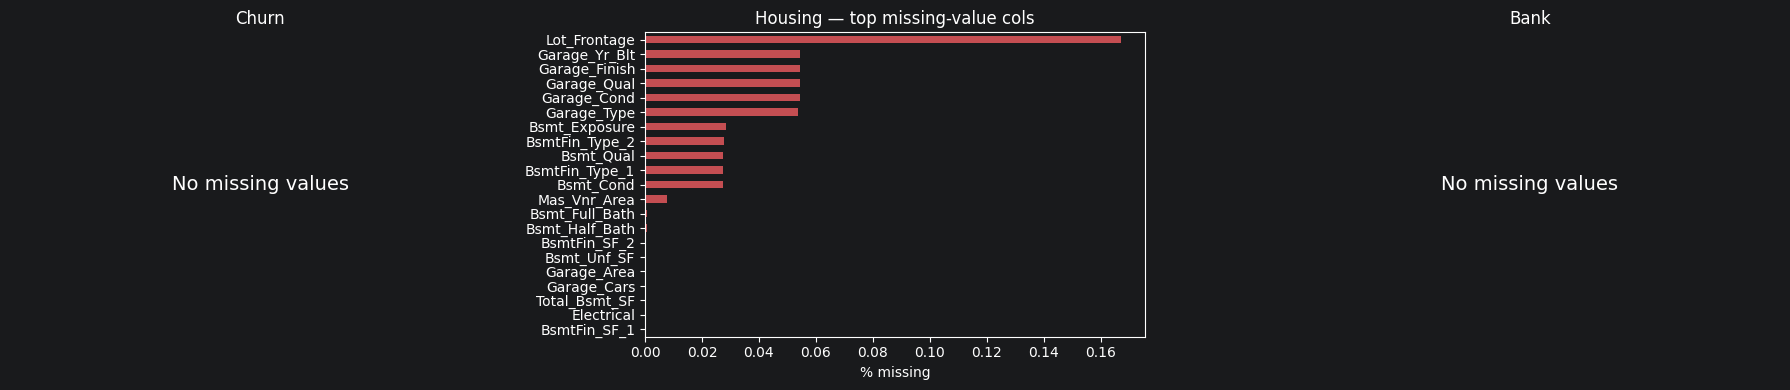

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

for ax, (name, (X, _)) in zip(axes, datasets.items()):
  missing = X.isnull().mean().sort_values(ascending=False)
  missing = missing[missing > 0].head(15)
  if len(missing) == 0:
      ax.text(0.5, 0.5, "No missing values", ha="center", va="center", fontsize=14)
      ax.set_title(f"{name}")
      ax.axis("off")
  else:
      missing.plot.barh(ax=ax, color="#C44E52")
      ax.set_title(f"{name} — top missing-value cols")
      ax.set_xlabel("% missing")
      ax.invert_yaxis()

plt.tight_layout()
plt.savefig(FIGURES_DIR / "02_missing_values.png", bbox_inches="tight")
plt.show()

### Correlation with target

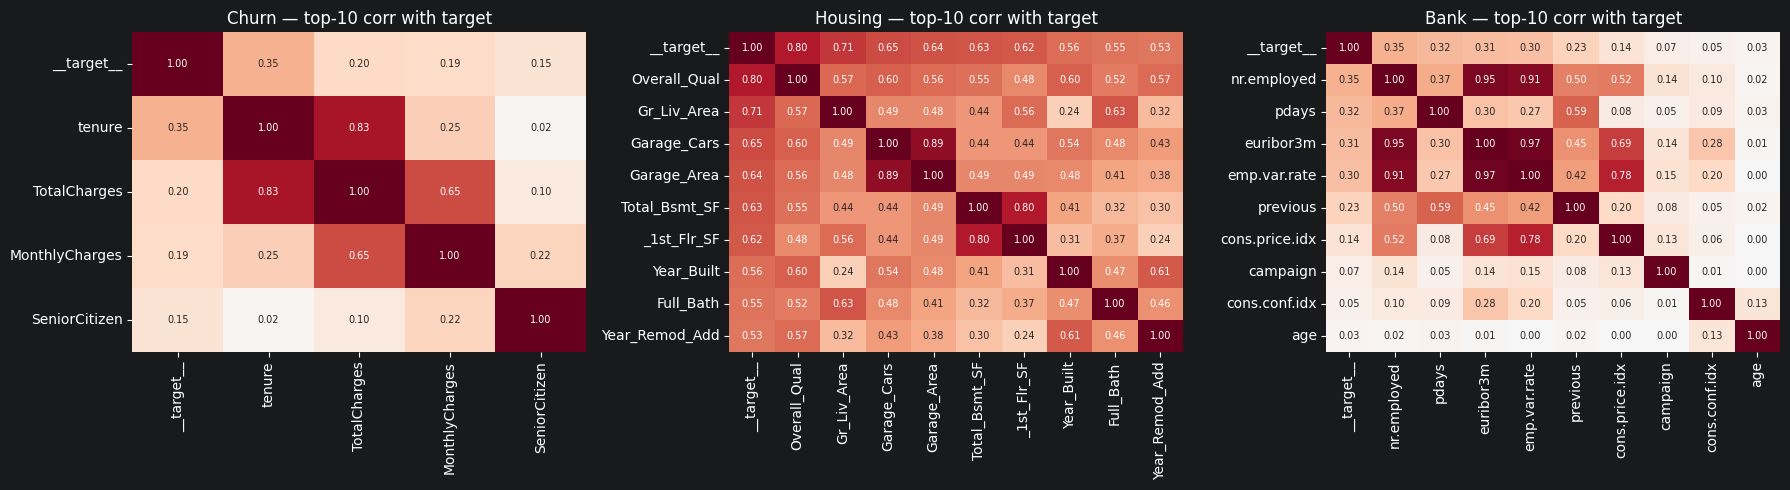

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (name, (X, y)) in zip(axes, datasets.items()):
  df_with_target = X.select_dtypes(include=np.number).copy()
  df_with_target["__target__"] = y.values
  corr = df_with_target.corr().abs()

  top_features = corr["__target__"].sort_values(ascending=False).head(10).index
  sns.heatmap(corr.loc[top_features, top_features], cmap="RdBu_r", center=0,
              ax=ax, annot=True, fmt=".2f", cbar=False, annot_kws={"size": 7})
  ax.set_title(f"{name} — top-10 corr with target")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "03_correlations.png", bbox_inches="tight")
plt.show()

### Print all column names a.k.a feature names

In [13]:
for name, (X, _) in datasets.items():
  print(f"\n{'='*70}")
  print(f"{name} — {X.shape[1]} columns")
  print('='*70)
  print(", ".join(X.columns.tolist()))


Churn — 19 columns
gender, SeniorCitizen, Partner, Dependents, tenure, PhoneService, MultipleLines, InternetService, OnlineSecurity, OnlineBackup, DeviceProtection, TechSupport, StreamingTV, StreamingMovies, Contract, PaperlessBilling, PaymentMethod, MonthlyCharges, TotalCharges

Housing — 73 columns
MS_SubClass, MS_Zoning, Lot_Frontage, Lot_Area, Street, Lot_Shape, Land_Contour, Utilities, Lot_Config, Land_Slope, Neighborhood, Condition_1, Condition_2, Bldg_Type, House_Style, Overall_Qual, Overall_Cond, Year_Built, Year_Remod_Add, Roof_Style, Roof_Matl, Exterior_1st, Exterior_2nd, Mas_Vnr_Area, Exter_Qual, Exter_Cond, Foundation, Bsmt_Qual, Bsmt_Cond, Bsmt_Exposure, BsmtFin_Type_1, BsmtFin_SF_1, BsmtFin_Type_2, BsmtFin_SF_2, Bsmt_Unf_SF, Total_Bsmt_SF, Heating, Heating_QC, Central_Air, Electrical, _1st_Flr_SF, _2nd_Flr_SF, Low_Qual_Fin_SF, Gr_Liv_Area, Bsmt_Full_Bath, Bsmt_Half_Bath, Full_Bath, Half_Bath, Bedroom_AbvGr, Kitchen_AbvGr, Kitchen_Qual, TotRms_AbvGrd, Functional, Fireplac

### Test LLM call

In [15]:
# Build a prompt for churn
cfg = DATASET_CONFIG["churn"]
prompt = build_zero_shot_prompt(
    dataset_name=cfg["display_name"],
    task=cfg["task"],
    target=cfg["target"],
    columns=list(X_churn.columns),
)
print("Prompt first 500 chars:\n")
print(prompt[:500] + "...\n")

# Ask GPT-4o-mini
llm = LLMClient("gpt-4o-mini")
features, _ = llm.suggest_features(
    prompt=prompt,
    dataset_name="churn",
    prompt_variant="zero_shot"
)

print("\nLLM-suggested features:\n")
for i, f in enumerate(features, 1):
    print(f"{i}. {f['name']}")
    print(f"   formula:   {f['formula']}")
    print(f"   rationale: {f['rationale']}\n")



Prompt first 500 chars:

You are a senior data scientist working on a binary classification problem.

Dataset: Telco Customer Churn
Target variable: Churn (whether the customer left)
Available columns: gender, SeniorCitizen, Partner, Dependents, tenure, PhoneService, MultipleLines, InternetService, OnlineSecurity, OnlineBackup, DeviceProtection, TechSupport, StreamingTV, StreamingMovies, Contract, PaperlessBilling, PaymentMethod, MonthlyCharges, TotalCharges

Suggest exactly 7 new engineered features that could improve ...


LLM-suggested features:

1. tenure_months
   formula:   tenure * 30
   rationale: Converts tenure into a more interpretable unit of months, which may correlate with churn.

2. high_monthly_charges
   formula:   MonthlyCharges > 80
   rationale: Flags customers with high monthly charges, who may be more likely to churn.

3. total_charges_per_tenure
   formula:   TotalCharges / (tenure + 1).clip(lower=1)
   rationale: Calculates the average charges per month, providi